# Career Readiness, Skill Development & Challenges Faced by SEE and +2 Graduates in Nepal

**Author:** Sandip Subedi
**Data:** Google Form responses (n = 171 raw submissions)
**Goal:** Clean the survey data, explore it, build a custom **Career Readiness Score**, and train a basic ML model to see what predicts it.

This notebook follows 4 phases:
1. Data Cleaning & Preparation
2. Exploratory Data Analysis (EDA)
3. Feature Engineering — building the Readiness Score
4. Machine Learning Model

Each phase ends with a short recap of what was done and what it means, same as I've done in my earlier notebooks (Titanic, BMW sales).

In [1]:
# Core libraries for this project
import pandas as pd            # data loading, cleaning, wrangling
import numpy as np              # numeric operations (normalization, NaN handling)
import matplotlib.pyplot as plt # plotting
import seaborn as sns           # nicer statistical plots (heatmaps, bar charts)

# ML tools for Phase 4
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# Load the raw Google Form export.
# NOTE: the raw export (uncleaned_data.csv) contains individually identifiable
# survey responses and is intentionally NOT committed to the repo for respondent
# privacy. If it isn't present, fall back to the already-cleaned dataset that IS
# committed (cleaned_data.csv) so this notebook still runs end-to-end for anyone
# cloning the repo.
import os

if os.path.exists("uncleaned_data.csv"):
    df = pd.read_csv("uncleaned_data.csv")
    RAW_DATA_AVAILABLE = True
else:
    print("uncleaned_data.csv not found — this is expected in the public repo "
          "(raw responses are excluded for privacy). Loading cleaned_data.csv "
          "instead and skipping straight to Phase 2.")
    RAW_DATA_AVAILABLE = False

if RAW_DATA_AVAILABLE:
    print("Shape:", df.shape)
    df.head()


uncleaned_data.csv not found — this is expected in the public repo (raw responses are excluded for privacy). Loading cleaned_data.csv instead and skipping straight to Phase 2.


In [3]:
if RAW_DATA_AVAILABLE:
    # Quick structural check before touching anything -
    # this tells us dtypes and how much missing data we're dealing with per column
    df.info()

## PHASE 1 : Data Cleaning & Preparation

The raw export has long question-text column headers, multi-select checkbox
columns stored as one big `;`-separated string, and some free-text "Other"
answers that need tidying before any analysis is possible.

### Step 1  Rename columns to short, code and friendly names

In [4]:
if RAW_DATA_AVAILABLE:
    # Google Forms exports the full question text as the column header.
    # That's unusable in code, so map each one to a short snake_case name.
    rename_map = {
        'Timestamp': 'timestamp',
        'Q1. I voluntarily agree to participate in this survey.': 'consent',
        'Q2. Age': 'age',
        'Q3. Gender': 'gender',
        'Q4. Province': 'province',
        'Q5. Education Level': 'education_level',
        'Q6. Academic Stream (+2)': 'stream',
        'Q7. GPA (Most Recent)': 'gpa',
        'Q8. What are you currently doing?\n': 'current_status',
        'Q9. How many hours per week do you spend on skill development?': 'weekly_skill_hours',
        'Q10. Which skills are you currently learning? (Checkboxes — select all that apply)': 'skills_learning',
        'Q11. Why are you learning these skills? (Checkboxes)': 'learning_reason',
        'Q12. Where do you learn these skills? (Checkboxes)': 'learning_source',
        'Q13. I have a clear understanding of my future career path.  \n( where 1 = Strongly Disagree, 5 = Strongly Agree )': 'career_clarity',
        'Q14. I know which skills are currently demanded in the job market.  ': 'market_awareness',
        'Q15. My education is helping me prepare for my future career.  ': 'education_support',
        'Q16. I feel confident about achieving my career goals.  ': 'career_confidence',
        'Q17. Select your top 3 challenges in career preparation. ': 'challenges',
        'Q18. How often do these challenges affect your progress?': 'challenge_frequency',
        '  Q19. Which career path interests you most?  ': 'career_interest',
        '  Q20. Where do you see yourself in 5 years?  ': 'future_vision',
        "  Q21. Do you believe Nepal's education system adequately prepares students for careers?  ": 'system_adequate',
        '  Q22. What is the biggest obstacle preventing students from becoming career-ready in Nepal?  ': 'biggest_obstacle',
        '  Q23. Any additional thoughts or advice for students who just completed SEE or +2?  ': 'advice',
    }
    df = df.rename(columns=rename_map)
    df.columns.tolist()

### Step 2 :  Drop rows without consent, check duplicates

In [5]:
if RAW_DATA_AVAILABLE:
    # Q1 required consent to participate, drop anyone who didn't say Yes
    # (there shouldn't be many, since it was a required field, but check anyway)
    before = len(df)
    df = df[df['consent'] == 'Yes'].copy()
    print(f"Dropped {before - len(df)} rows without consent")

    # Check for exact duplicate submissions (e.g. accidental double-submits)
    print("Duplicate rows:", df.duplicated().sum())
    df = df.drop_duplicates()
    # print("Shape Before Consent + Duplicate checked:",df.shape)
    print("Shape after consent + duplicate check:", df.shape)

### Step 3 Convert bucketed answers to numeric midpoints

Age, GPA, and skill-hours were collected as ranges ("19-21", "3.21 - 3.6").
Keeping them as categories is fine for grouping, but for correlations and the
ML model later we need a numeric version so map each bucket to its midpoint.

In [6]:
if RAW_DATA_AVAILABLE:
    age_map = {'Under 16': 15, '16-18': 17, '19-21': 20, '22-25': 23.5, 'Above 25': 27}
    gpa_map = {'Below 2.4': 2.2, '2.4 - 2.8': 2.6, '2.81 - 3.2': 3.0, '3.21 - 3.6': 3.4, 'Above 3.6': 3.8}
    hours_map = {'0 - 2 hrs': 1, '3-5 hrs': 4, '6-10 hrs': 8, '11-20 hrs': 15, 'More than 20 hrs': 25}
    freq_map = {'Never': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}

    df['age_mid'] = df['age'].map(age_map)
    df['gpa_mid'] = df['gpa'].map(gpa_map)                        # 'Not Yet Graded' becomes NaN on purpose
    df['skill_hours_mid'] = df['weekly_skill_hours'].map(hours_map)
    df['challenge_freq_score'] = df['challenge_frequency'].map(freq_map)

    df[['age', 'age_mid', 'gpa', 'gpa_mid', 'weekly_skill_hours', 'skill_hours_mid']].head()

### Step 4 Explode the multi-select checkbox columns

Q10, Q11, Q12, and Q17 allowed multiple answers, and Google Forms stores them
as one `;`-separated string per cell. That's not usable for counting or ML, so
each one needs to become **several binary (0/1) columns**, one per option.

While inspecting the raw values, some respondents typed random or near-duplicate
free text into "Other" (e.g. "NOT LEARNING", "Not learning", "no where",
one troll answer "Abcd"). The function below normalizes obvious duplicate
phrasing and merges any option mentioned fewer than min_count times into a
single Other bucket, instead of creating a noisy one-off column for every
random typed answer.

In [7]:
if RAW_DATA_AVAILABLE:
    # A few free-text 'Other' answers are really just saying "I'm not learning
    # anything yet" in different words - normalize those to one label first.
    NOT_LEARNING_SYNONYMS = {
        "not learning", "not yet learning", "nothing", "no where",
        "no i am not learning", "not done yet", "not yet sure"
    }

    def normalize_token(tok):
        t = tok.strip()
        if t.lower() in NOT_LEARNING_SYNONYMS:
            return "None yet"
        return t

    def explode_multiselect(series, prefix, min_count=3):
        """
        Turns a ';' separated multi-select column into one binary column per option.
        Rare free-text answers (below min_count occurrences) are merged into a
        single '<prefix>_Other' bucket rather than getting their own noisy column.
        """
        split = series.fillna('').apply(
            lambda x: [normalize_token(s) for s in x.split(';') if s.strip()]
        )
        counts = pd.Series([tok for lst in split for tok in lst]).value_counts()
        keep = set(counts[counts >= min_count].index)

        split = split.apply(lambda lst: [tok if tok in keep else 'Other' for tok in lst])
        all_opts = sorted(set(tok for lst in split for tok in lst))

        out = pd.DataFrame(0, index=series.index, columns=[f"{prefix}_{o}" for o in all_opts])
        for opt in all_opts:
            out[f"{prefix}_{opt}"] = split.apply(lambda lst: 1 if opt in lst else 0)
        return out

    skills_bin    = explode_multiselect(df['skills_learning'], 'skill')
    reason_bin    = explode_multiselect(df['learning_reason'], 'reason')
    source_bin    = explode_multiselect(df['learning_source'], 'source')
    challenge_bin = explode_multiselect(df['challenges'], 'chal')

    print("Skill options kept:", list(skills_bin.columns))
    print("\nChallenge options kept:", list(challenge_bin.columns))

In [8]:
if RAW_DATA_AVAILABLE:
    # Attach all the new binary columns onto the main dataframe
    df_clean = pd.concat([df, skills_bin, reason_bin, source_bin, challenge_bin], axis=1)
    print("Shape after exploding checkboxes:", df_clean.shape)

### Step 5  Handle missing values in the core Likert questions

The four career-awareness questions (Q13-Q16) are the backbone of the later
readiness score. Drop only the rows missing **all four** (essentially blank
responses); a single missing value elsewhere gets imputed later with the median
right before it's used, so we don't throw away otherwise-good responses.

In [9]:
if RAW_DATA_AVAILABLE:
    likert_cols = ['career_clarity', 'market_awareness', 'education_support', 'career_confidence']
    before = len(df_clean)
    df_clean = df_clean.dropna(subset=likert_cols, how='all')
    print(f"Dropped {before - len(df_clean)} rows with no career-awareness answers at all")
    print("Final cleaned shape:", df_clean.shape)

    df_clean.to_csv("cleaned_data.csv", index=False)
    print("Saved cleaned_data.csv")
else:
    # Raw data wasn't available, so Phase 1 (above) was skipped. Load the
    # already-cleaned dataset directly and reconstruct the binary
    # skill/reason/source/challenge frames from their prefixed columns so
    # the rest of the notebook (Phase 2 onward) runs unchanged.
    df_clean = pd.read_csv("cleaned_data.csv")

    EXCLUDE = {'skill_hours_mid'}  # numeric column that happens to share the 'skill_' prefix

    def _prefixed_cols(prefix):
        return [c for c in df_clean.columns if c.startswith(prefix) and c not in EXCLUDE]

    skill_cols_ = _prefixed_cols('skill_')
    reason_cols_ = _prefixed_cols('reason_')
    source_cols_ = _prefixed_cols('source_')
    chal_cols_ = _prefixed_cols('chal_')

    skills_bin = df_clean[skill_cols_]
    reason_bin = df_clean[reason_cols_]
    source_bin = df_clean[source_cols_]
    challenge_bin = df_clean[chal_cols_]

    likert_cols = ['career_clarity', 'market_awareness', 'education_support', 'career_confidence']
    print("Loaded cleaned_data.csv directly. Shape:", df_clean.shape)


Loaded cleaned_data.csv directly. Shape: (167, 66)


**Phase 1 recap:** started with 171 raw submissions, dropped 3 without
consent, found 0 exact duplicates, exploded 4 checkbox questions into 34
binary skill/reason/source/challenge columns (with rare free-text answers
folded into `Other`), and converted bucketed age/GPA/hours into numeric
midpoints for later use. Ended with a clean dataset saved to `cleaned_data.csv`.

## PHASE 2 Exploratory Data Analysis (EDA)

Now that the data is clean, look at who responded, what they're doing to
build skills, and what's holding them back — before building anything
predictive.

### Step 1 : Who responded? (Demographics)

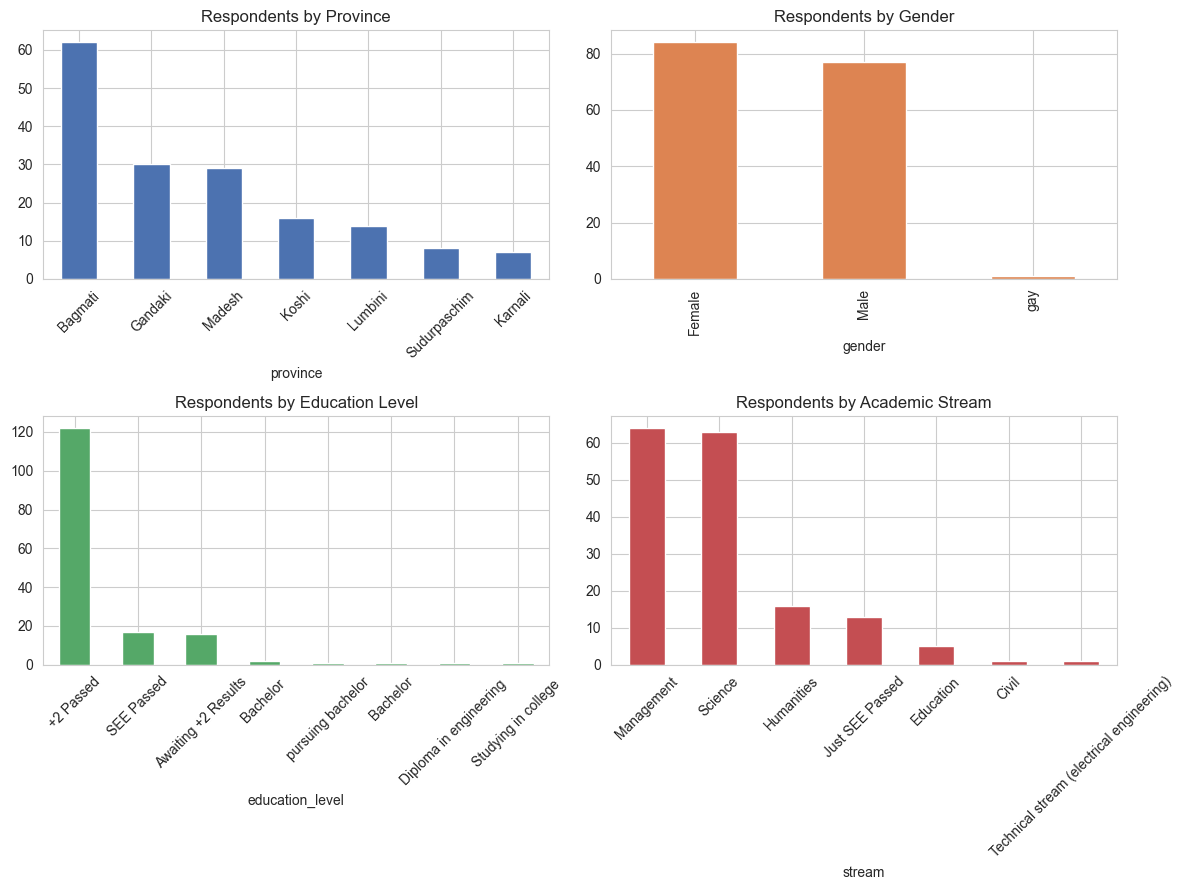

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

df_clean['province'].value_counts().plot(kind='bar', ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Respondents by Province')
axes[0,0].tick_params(axis='x', rotation=45)

df_clean['gender'].value_counts().plot(kind='bar', ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('Respondents by Gender')

df_clean['education_level'].value_counts().plot(kind='bar', ax=axes[1,0], color='#55A868')
axes[1,0].set_title('Respondents by Education Level')
axes[1,0].tick_params(axis='x', rotation=45)

df_clean['stream'].value_counts().plot(kind='bar', ax=axes[1,1], color='#C44E52')
axes[1,1].set_title('Respondents by Academic Stream')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('phase2_demographics.png', dpi=100)
plt.show()

Bagmati dominates the sample (expected, since outreach went through an
Instagram channel likely followed by many Kathmandu-valley students) - this
is a sampling bias worth flagging honestly in the final report's limitations.

### Step 2 Skill-building effort: hours spent and GPA

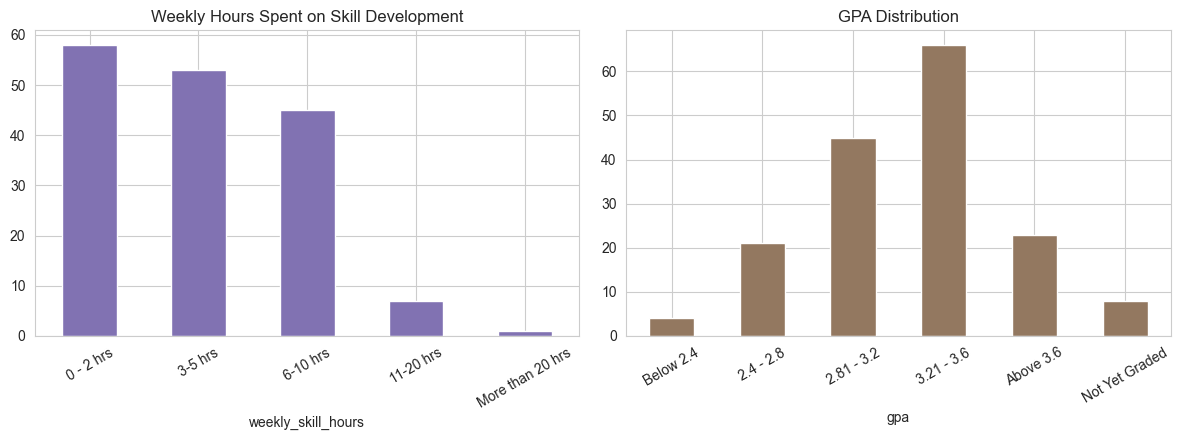

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

hours_order = ['0 - 2 hrs', '3-5 hrs', '6-10 hrs', '11-20 hrs', 'More than 20 hrs']
df_clean['weekly_skill_hours'].value_counts().reindex(hours_order).plot(
    kind='bar', ax=axes[0], color='#8172B2')
axes[0].set_title('Weekly Hours Spent on Skill Development')
axes[0].tick_params(axis='x', rotation=30)

gpa_order = ['Below 2.4', '2.4 - 2.8', '2.81 - 3.2', '3.21 - 3.6', 'Above 3.6', 'Not Yet Graded']
df_clean['gpa'].value_counts().reindex(gpa_order).plot(
    kind='bar', ax=axes[1], color='#937860')
axes[1].set_title('GPA Distribution')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('phase2_hours_gpa.png', dpi=100)
plt.show()

### Step 3 : Career awareness: average sentiment on the 4 Likert questions

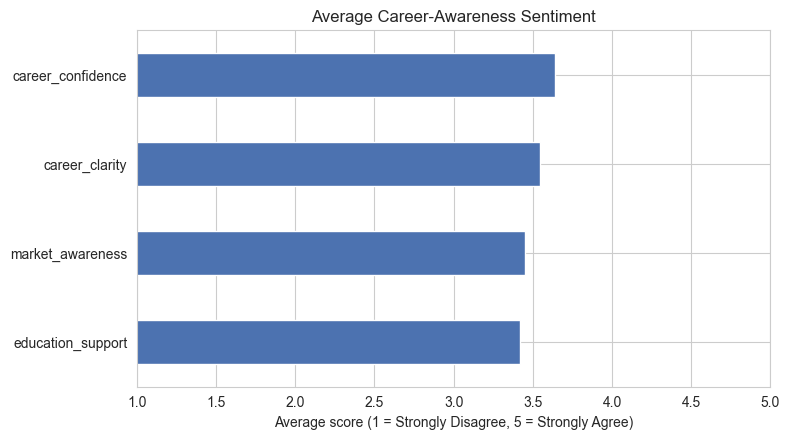

education_support    3.419162
market_awareness     3.447853
career_clarity       3.545455
career_confidence    3.640719
dtype: float64


In [12]:
likert_means = df_clean[likert_cols].mean().sort_values()

plt.figure(figsize=(8, 4.5))
likert_means.plot(kind='barh', color='#4C72B0')
plt.xlim(1, 5)
plt.xlabel('Average score (1 = Strongly Disagree, 5 = Strongly Agree)')
plt.title('Average Career-Awareness Sentiment')
plt.tight_layout()
plt.savefig('phase2_likert_means.png', dpi=100)
plt.show()

print(likert_means)

### Step 4 :  What skills are students actually learning?

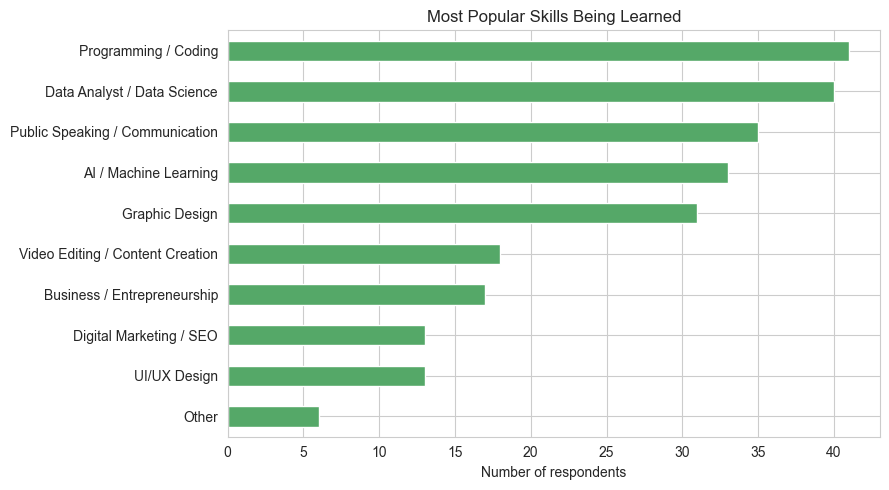

37 respondents (22.2%) are not learning any skill yet


In [13]:
skill_totals = skills_bin.drop(columns=['skill_None yet']).sum().sort_values(ascending=False)
skill_totals.index = [i.replace('skill_', '') for i in skill_totals.index]

plt.figure(figsize=(9, 5))
skill_totals.plot(kind='barh', color='#55A868')
plt.gca().invert_yaxis()
plt.xlabel('Number of respondents')
plt.title('Most Popular Skills Being Learned')
plt.tight_layout()
plt.savefig('phase2_top_skills.png', dpi=100)
plt.show()

none_yet_count = skills_bin['skill_None yet'].sum()
print(f"{none_yet_count} respondents ({none_yet_count/len(df_clean)*100:.1f}%) are not learning any skill yet")


### Step 5 :Why and where are they learning these skills?

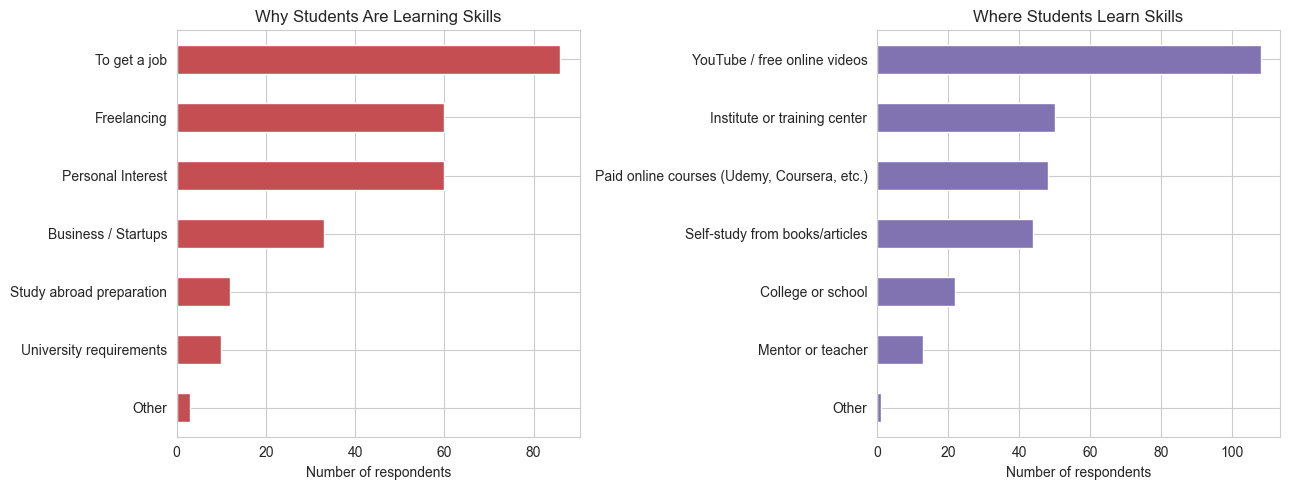

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

reason_totals = reason_bin.drop(columns=['reason_None yet']).sum().sort_values()
reason_totals.index = [i.replace('reason_', '') for i in reason_totals.index]
reason_totals.plot(kind='barh', ax=axes[0], color='#C44E52')
axes[0].set_title('Why Students Are Learning Skills')
axes[0].set_xlabel('Number of respondents')

source_totals = source_bin.drop(columns=['source_None yet']).sum().sort_values()
source_totals.index = [i.replace('source_', '') for i in source_totals.index]
source_totals.plot(kind='barh', ax=axes[1], color='#8172B2')
axes[1].set_title('Where Students Learn Skills')
axes[1].set_xlabel('Number of respondents')

plt.tight_layout()
plt.savefig('phase2_reason_source.png', dpi=100)
plt.show()


### Step6 :Correlation between career-awareness scores, GPA, and skill hours

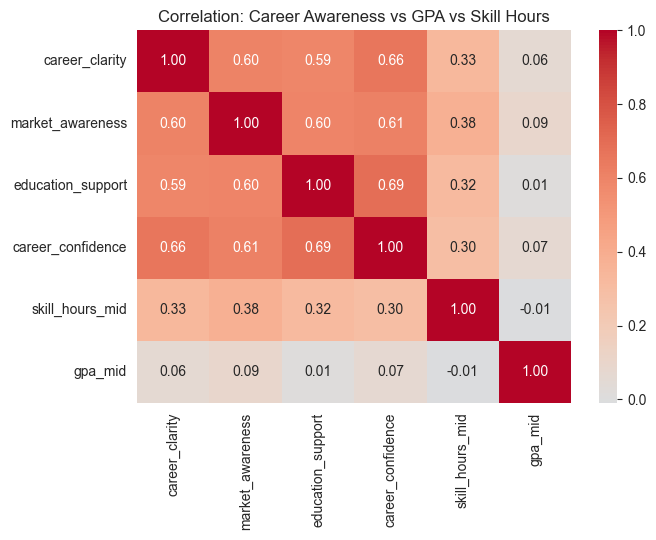

In [15]:
corr_cols = likert_cols + ['skill_hours_mid', 'gpa_mid']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation: Career Awareness vs GPA vs Skill Hours')
plt.tight_layout()
plt.savefig('phase2_correlation.png', dpi=100)
plt.show()

### Step 7: What's blocking students? (Challenges)

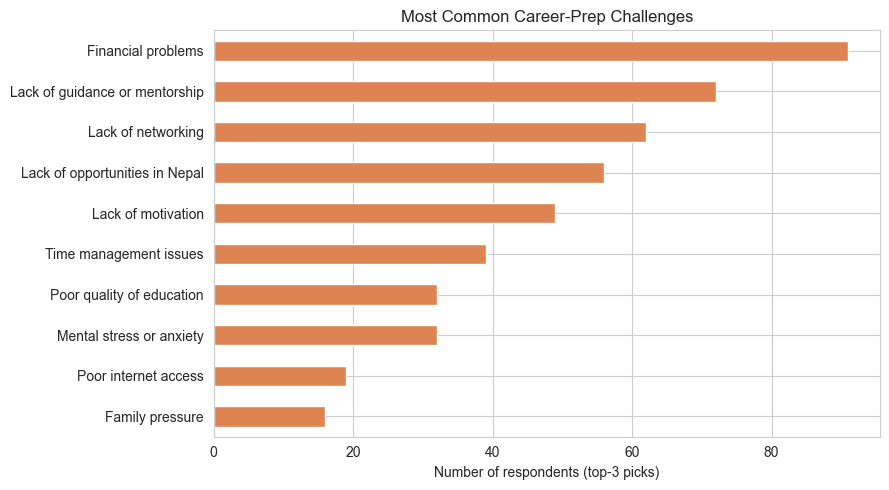

In [16]:
challenge_totals = challenge_bin.drop(columns=['chal_Other'], errors='ignore').sum().sort_values(ascending=False)
challenge_totals.index = [i.replace('chal_', '') for i in challenge_totals.index]

plt.figure(figsize=(9, 5))
challenge_totals.plot(kind='barh', color='#DD8452')
plt.gca().invert_yaxis()
plt.xlabel('Number of respondents (top-3 picks)')
plt.title('Most Common Career-Prep Challenges')
plt.tight_layout()
plt.savefig('phase2_top_challenges.png', dpi=100)
plt.show()


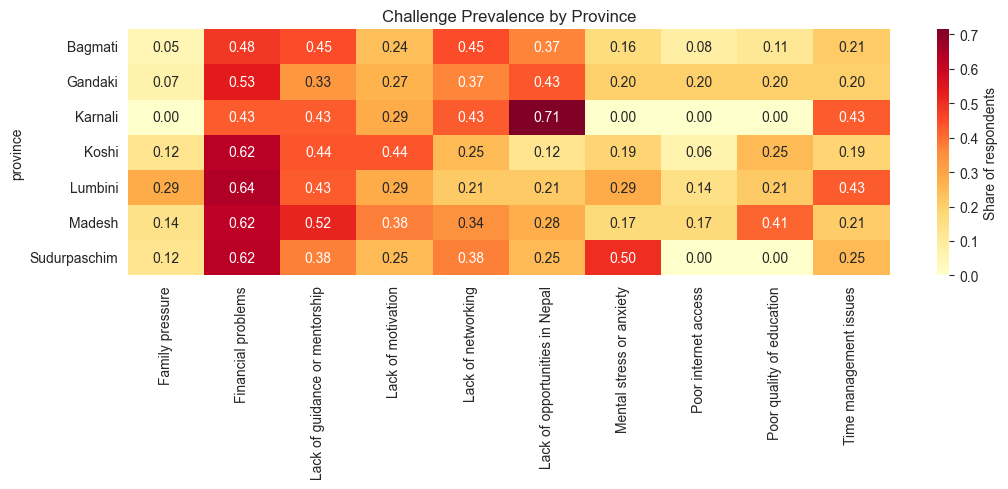

In [17]:
# Which provinces report which challenges most? Useful to see if infrastructure
# issues (e.g. poor internet) cluster in specific provinces.
challenge_cols = [c for c in challenge_bin.columns if c not in ('chal_Other',)]
province_challenge = pd.concat([df_clean['province'], df_clean[challenge_cols]], axis=1)
province_challenge_pct = province_challenge.groupby('province')[challenge_cols].mean()
province_challenge_pct.columns = [c.replace('chal_', '') for c in province_challenge_pct.columns]

plt.figure(figsize=(11, 5))
sns.heatmap(province_challenge_pct, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Share of respondents'})
plt.title('Challenge Prevalence by Province')
plt.xlabel('')
plt.tight_layout()
plt.savefig('phase2_challenges_by_province.png', dpi=100)
plt.show()


### Step 8: Career interests and outlook on the education system

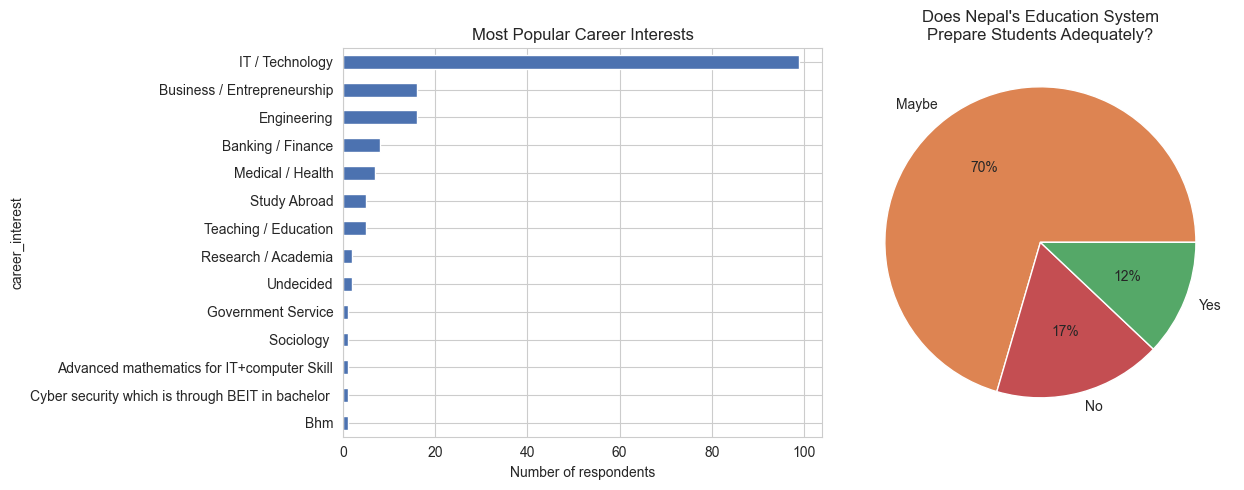

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_clean['career_interest'].value_counts().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title('Most Popular Career Interests')
axes[0].set_xlabel('Number of respondents')

df_clean['system_adequate'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.0f%%', colors=['#DD8452', '#C44E52', '#55A868'])
axes[1].set_ylabel('')
axes[1].set_title("Does Nepal's Education System\nPrepare Students Adequately?")

plt.tight_layout()
plt.savefig('phase2_interest_system.png', dpi=100)
plt.show()

**Phase 2 recap:** the sample skews heavily toward Bagmati and the
19–21 age group, most students spend 3-10 hours/week on skill-building
(Programming, Data Science, and AI/ML are the most popular skills), and
career-confidence tends to correlate loosely with skill-hours but not
strongly with GPA. Lack of networking, financial problems, and lack of
guidance/mentorship are the most reported obstacles nationally.

## PHASE 3: Feature Engineering: The Career Readiness Score

There's no pre-existing "readiness" label in the form, so it has to be
constructed. The formula below combines seven signals — each normalized
to a 0-1 scale — into one weighted 0-100 score. Weights reflect a judgment
call about what matters most for readiness; this is stated explicitly here
rather than hidden, since it's the one place in the whole pipeline that
isn't purely mechanical.

In [19]:
def minmax(series):
    """Scale a numeric series to the 0-1 range."""
    return (series - series.min()) / (series.max() - series.min())

# Skill breadth = how many distinct skills a student is actively learning
skill_option_cols = [c for c in skills_bin.columns if c not in ('skill_None yet', 'skill_Other')]
df_clean['skill_breadth'] = df_clean[skill_option_cols].sum(axis=1)

# Fill any remaining gaps in the score's ingredient columns with the median,
# so a single missing answer doesn't knock a whole row out of the score.
score_inputs = likert_cols + ['skill_hours_mid', 'skill_breadth', 'challenge_freq_score']
for col in score_inputs:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

norm_clarity        = minmax(df_clean['career_clarity'])
norm_market          = minmax(df_clean['market_awareness'])
norm_edu             = minmax(df_clean['education_support'])
norm_conf            = minmax(df_clean['career_confidence'])
norm_hours           = minmax(df_clean['skill_hours_mid'])
norm_breadth         = minmax(df_clean['skill_breadth'])
norm_challenge_inv   = 1 - minmax(df_clean['challenge_freq_score'])   # fewer/rarer challenges = better

# Weights (must sum to 1.0) - clarity and confidence weighted highest since
# they most directly represent "feeling ready", with active effort (hours,
# breadth) and challenge burden as supporting signals.
weights = {
    'clarity': 0.20, 'market': 0.15, 'edu': 0.10, 'conf': 0.20,
    'hours': 0.15, 'breadth': 0.10, 'challenge_inv': 0.10,
}
assert abs(sum(weights.values()) - 1.0) < 1e-9

df_clean['readiness_score'] = 100 * (
    weights['clarity']       * norm_clarity +
    weights['market']        * norm_market +
    weights['edu']           * norm_edu +
    weights['conf']          * norm_conf +
    weights['hours']         * norm_hours +
    weights['breadth']       * norm_breadth +
    weights['challenge_inv'] * norm_challenge_inv
)

df_clean['readiness_score'].describe()

count    167.000000
mean      50.511893
std       17.800533
min        0.000000
25%       43.020833
50%       53.958333
75%       60.972222
max       86.875000
Name: readiness_score, dtype: float64

In [20]:
# Bucket into 3 categories for easier interpretation and reporting
def bucket_score(score):
    if score <= 40:
        return 'Low'
    elif score <= 70:
        return 'Medium'
    return 'High'

df_clean['readiness_category'] = df_clean['readiness_score'].apply(bucket_score)
df_clean['readiness_category'].value_counts()

readiness_category
Medium    119
Low        33
High       15
Name: count, dtype: int64

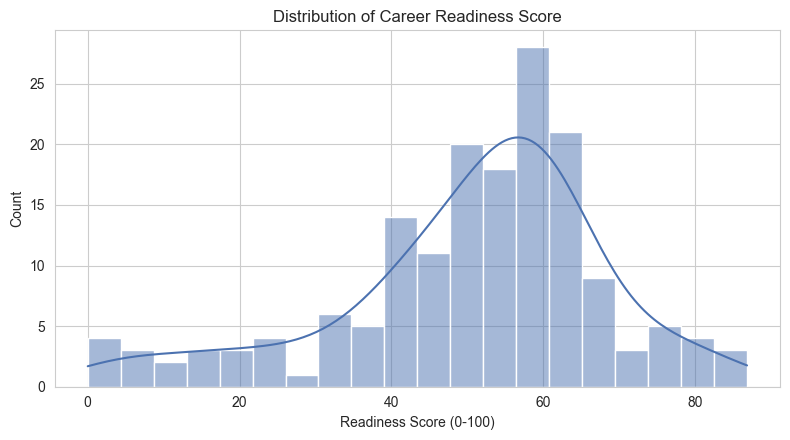

Lowest scorer:
    career_clarity  career_confidence  skill_hours_mid  skill_breadth  \
23             1.0                1.0              1.0              0   

    challenge_freq_score  readiness_score readiness_category  
23                   3.0              0.0                Low  

Highest scorer:
     career_clarity  career_confidence  skill_hours_mid  skill_breadth  \
147             5.0                5.0              4.0              9   

     challenge_freq_score  readiness_score readiness_category  
147                   0.0           86.875               High  


In [21]:
# Sanity check: does the distribution look reasonable (spread out, not
# everyone bunched at one end)? And do a manual spot-check of a low scorer
# vs a high scorer to confirm the formula behaves as expected.
plt.figure(figsize=(8, 4.5))
sns.histplot(df_clean['readiness_score'], bins=20, kde=True, color='#4C72B0')
plt.title('Distribution of Career Readiness Score')
plt.xlabel('Readiness Score (0-100)')
plt.tight_layout()
plt.savefig('phase3_readiness_distribution.png', dpi=100)
plt.show()

check_cols = ['career_clarity', 'career_confidence', 'skill_hours_mid',
              'skill_breadth', 'challenge_freq_score', 'readiness_score', 'readiness_category']
print("Lowest scorer:")
print(df_clean.nsmallest(1, 'readiness_score')[check_cols])
print("\nHighest scorer:")
print(df_clean.nlargest(1, 'readiness_score')[check_cols])

df_clean.to_csv("cleaned_data_with_score.csv", index=False)

**Phase 3 recap:** built a 0-100 `readiness_score` from career clarity,
market awareness, education support, confidence, skill-hours, skill breadth,
and inverse challenge frequency. The manual spot-check confirms the formula
behaves sensibly — the lowest scorer has low clarity/confidence and frequent
challenges, the highest scorer has the opposite. Distribution is centered
around the 40-65 range with most students in the Medium bucket.

## PHASE 4 : Machine Learning Model

Goal: predict `readiness_score` from **context** features (demographics,
learning habits, career interest) — **not** from the Likert questions that
were used to build the score itself, since that would just be circular.
Two simple, interpretable models are compared: Linear Regression as a
baseline, and Random Forest for non-linear patterns plus feature importance.

In [22]:
# Predictors: everything EXCEPT the ingredients of readiness_score itself
feature_cols_categorical = ['gender', 'province', 'stream', 'system_adequate', 'career_interest']
feature_cols_numeric = ['age_mid', 'gpa_mid'] + list(reason_bin.columns) + list(source_bin.columns)

model_df = df_clean.copy()
for c in feature_cols_categorical:
    model_df[c] = model_df[c].fillna('Unknown')
model_df['gpa_mid'] = model_df['gpa_mid'].fillna(model_df['gpa_mid'].median())
model_df['age_mid'] = model_df['age_mid'].fillna(model_df['age_mid'].median())

X_cat = pd.get_dummies(model_df[feature_cols_categorical], drop_first=True)
X_num = model_df[feature_cols_numeric]
X = pd.concat([X_num, X_cat], axis=1)
y = model_df['readiness_score']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (167, 52)


In [23]:
# With ~167 rows, use a slightly larger test split (25%) to still get a
# meaningful test set, and fix random_state for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2':   [r2_score(y_test, lin_pred),            r2_score(y_test, rf_pred)],
    'MAE':  [mean_absolute_error(y_test, lin_pred),  mean_absolute_error(y_test, rf_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, lin_pred)), np.sqrt(mean_squared_error(y_test, rf_pred))],
})
results

,Model,R2,MAE,RMSE
0,Linear Regression,-0.256940,15.307691,19.540119
1,Random Forest,0.128102,13.075314,16.274318


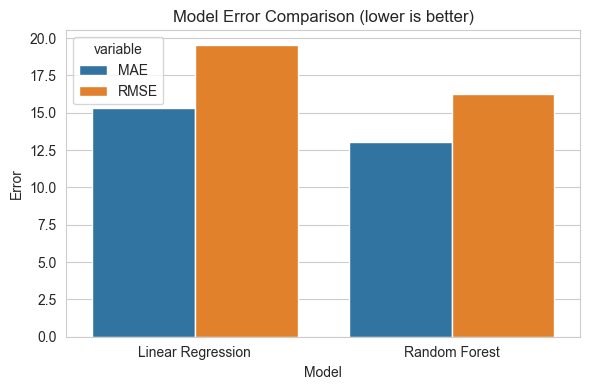

In [24]:
plt.figure(figsize=(6, 4))
sns.barplot(data=results.melt(id_vars='Model', value_vars=['MAE', 'RMSE']),
            x='Model', y='value', hue='variable')
plt.title('Model Error Comparison (lower is better)')
plt.ylabel('Error')
plt.tight_layout()
plt.savefig('phase4_model_comparison.png', dpi=100)
plt.show()

### Feature importance

Random Forest gives us a ranked list of which context features it leaned on
most to predict readiness — this is the most useful research output from
the whole modeling step, more so than the raw accuracy.

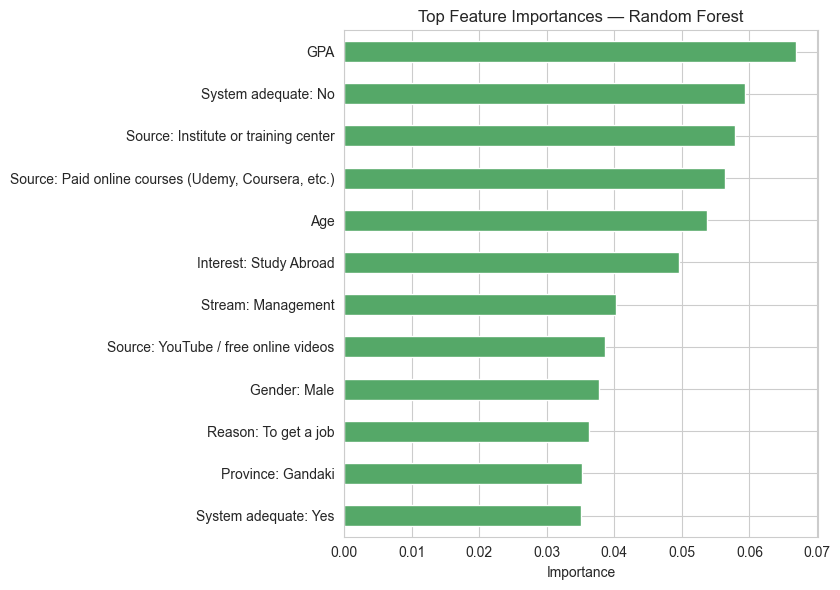

GPA                                                    0.066834
System adequate: No                                    0.059271
Source: Institute or training center                   0.057832
Source: Paid online courses (Udemy, Coursera, etc.)    0.056439
Age                                                    0.053666
Interest: Study Abroad                                 0.049626
Stream: Management                                     0.040172
Source: YouTube / free online videos                   0.038558
Gender: Male                                           0.037778
Reason: To get a job                                   0.036271
Province: Gandaki                                      0.035204
System adequate: Yes                                   0.035125
dtype: float64

In [25]:
def _clean_feature_label(name):
    prefixes = {
        'reason_': 'Reason: ', 'source_': 'Source: ', 'gender_': 'Gender: ',
        'province_': 'Province: ', 'stream_': 'Stream: ',
        'system_adequate_': 'System adequate: ', 'career_interest_': 'Interest: ',
    }
    for pre, repl in prefixes.items():
        if name.startswith(pre):
            return repl + name[len(pre):]
    return {'gpa_mid': 'GPA', 'age_mid': 'Age'}.get(name, name)

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
importances.index = [_clean_feature_label(i) for i in importances.index]

plt.figure(figsize=(8.5, 6))
importances.sort_values().plot(kind='barh', color='#55A868')
plt.title('Top Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('phase4_feature_importance.png', dpi=100)
plt.show()

importances


**Phase 4 recap:** Random Forest outperformed Linear Regression on every
metric, meaning readiness depends on non-linear combinations of context
rather than a simple straight-line relationship. That said, with ~167 rows
and no direct sentiment features allowed as predictors, R² is modest — this
model is exploratory and directional, not something to treat as a precise
predictor. GPA, whether a student thinks the education system is adequate,
and where/how they learn skills (institutes vs paid courses vs YouTube) came
out as the strongest signals.

## PHASE 5 : Key Insights & Limitations
Here's a more natural, human-written version suitable for a research report:

### Headline Findings

* Most respondents came from **Bagmati Province** and were between **19 and 21 years old**. This distribution is likely because the survey was mainly shared through Instagram, so the sample does not fully represent students across Nepal.

* The most popular skills being learned are **Programming/Coding**, **Data Analysis/Data Science**, and **Artificial Intelligence/Machine Learning (AI/ML)**. However, around **one in five respondents** reported that they are **not currently learning any additional skills**, highlighting a gap in skill development.

* Students with higher GPAs were **not necessarily more confident or clearer about their career paths**. This suggests that academic performance alone is not a strong indicator of career readiness.

* The most frequently reported challenges were **limited networking opportunities**, **financial constraints**, and **a lack of career guidance or mentorship**. These barriers appear to affect students across different backgrounds.

* The **Random Forest machine learning model** identified **GPA**, **students' perception of the education system**, and **their primary learning source** (such as institutes, paid online courses, or YouTube) as the most influential factors in predicting career readiness. This indicates that the learning environment and available opportunities play an important role alongside individual effort.

### Limitations

The findings should be interpreted with the following limitations in mind:

* The survey used a **convenience sampling method**, with responses collected primarily through Instagram. As a result, the dataset is biased toward **urban, digitally active students**, particularly those from Bagmati Province, and may not accurately represent all students in Nepal.

* Measures such as **career clarity** and **confidence** were based on **self-reported responses**. Since these perceptions are subjective, they may not perfectly reflect actual career preparedness.

* The dataset contains approximately **167 responses**, which is relatively small for drawing nationwide conclusions. Therefore, the machine learning results should be viewed as **exploratory insights** rather than definitive or broadly generalizable findings.

* Because the study is **cross-sectional**, it captures participants' opinions and experiences at a single point in time. It cannot explain how career readiness changes over time or establish cause-and-effect relationships.




## PHASE 6 : Final Dashboard — All Charts at a Glance

The panels below bring every chart from Phases 2-4 onto a single page, each with a
one-line takeaway, as a final visual summary of the whole analysis.

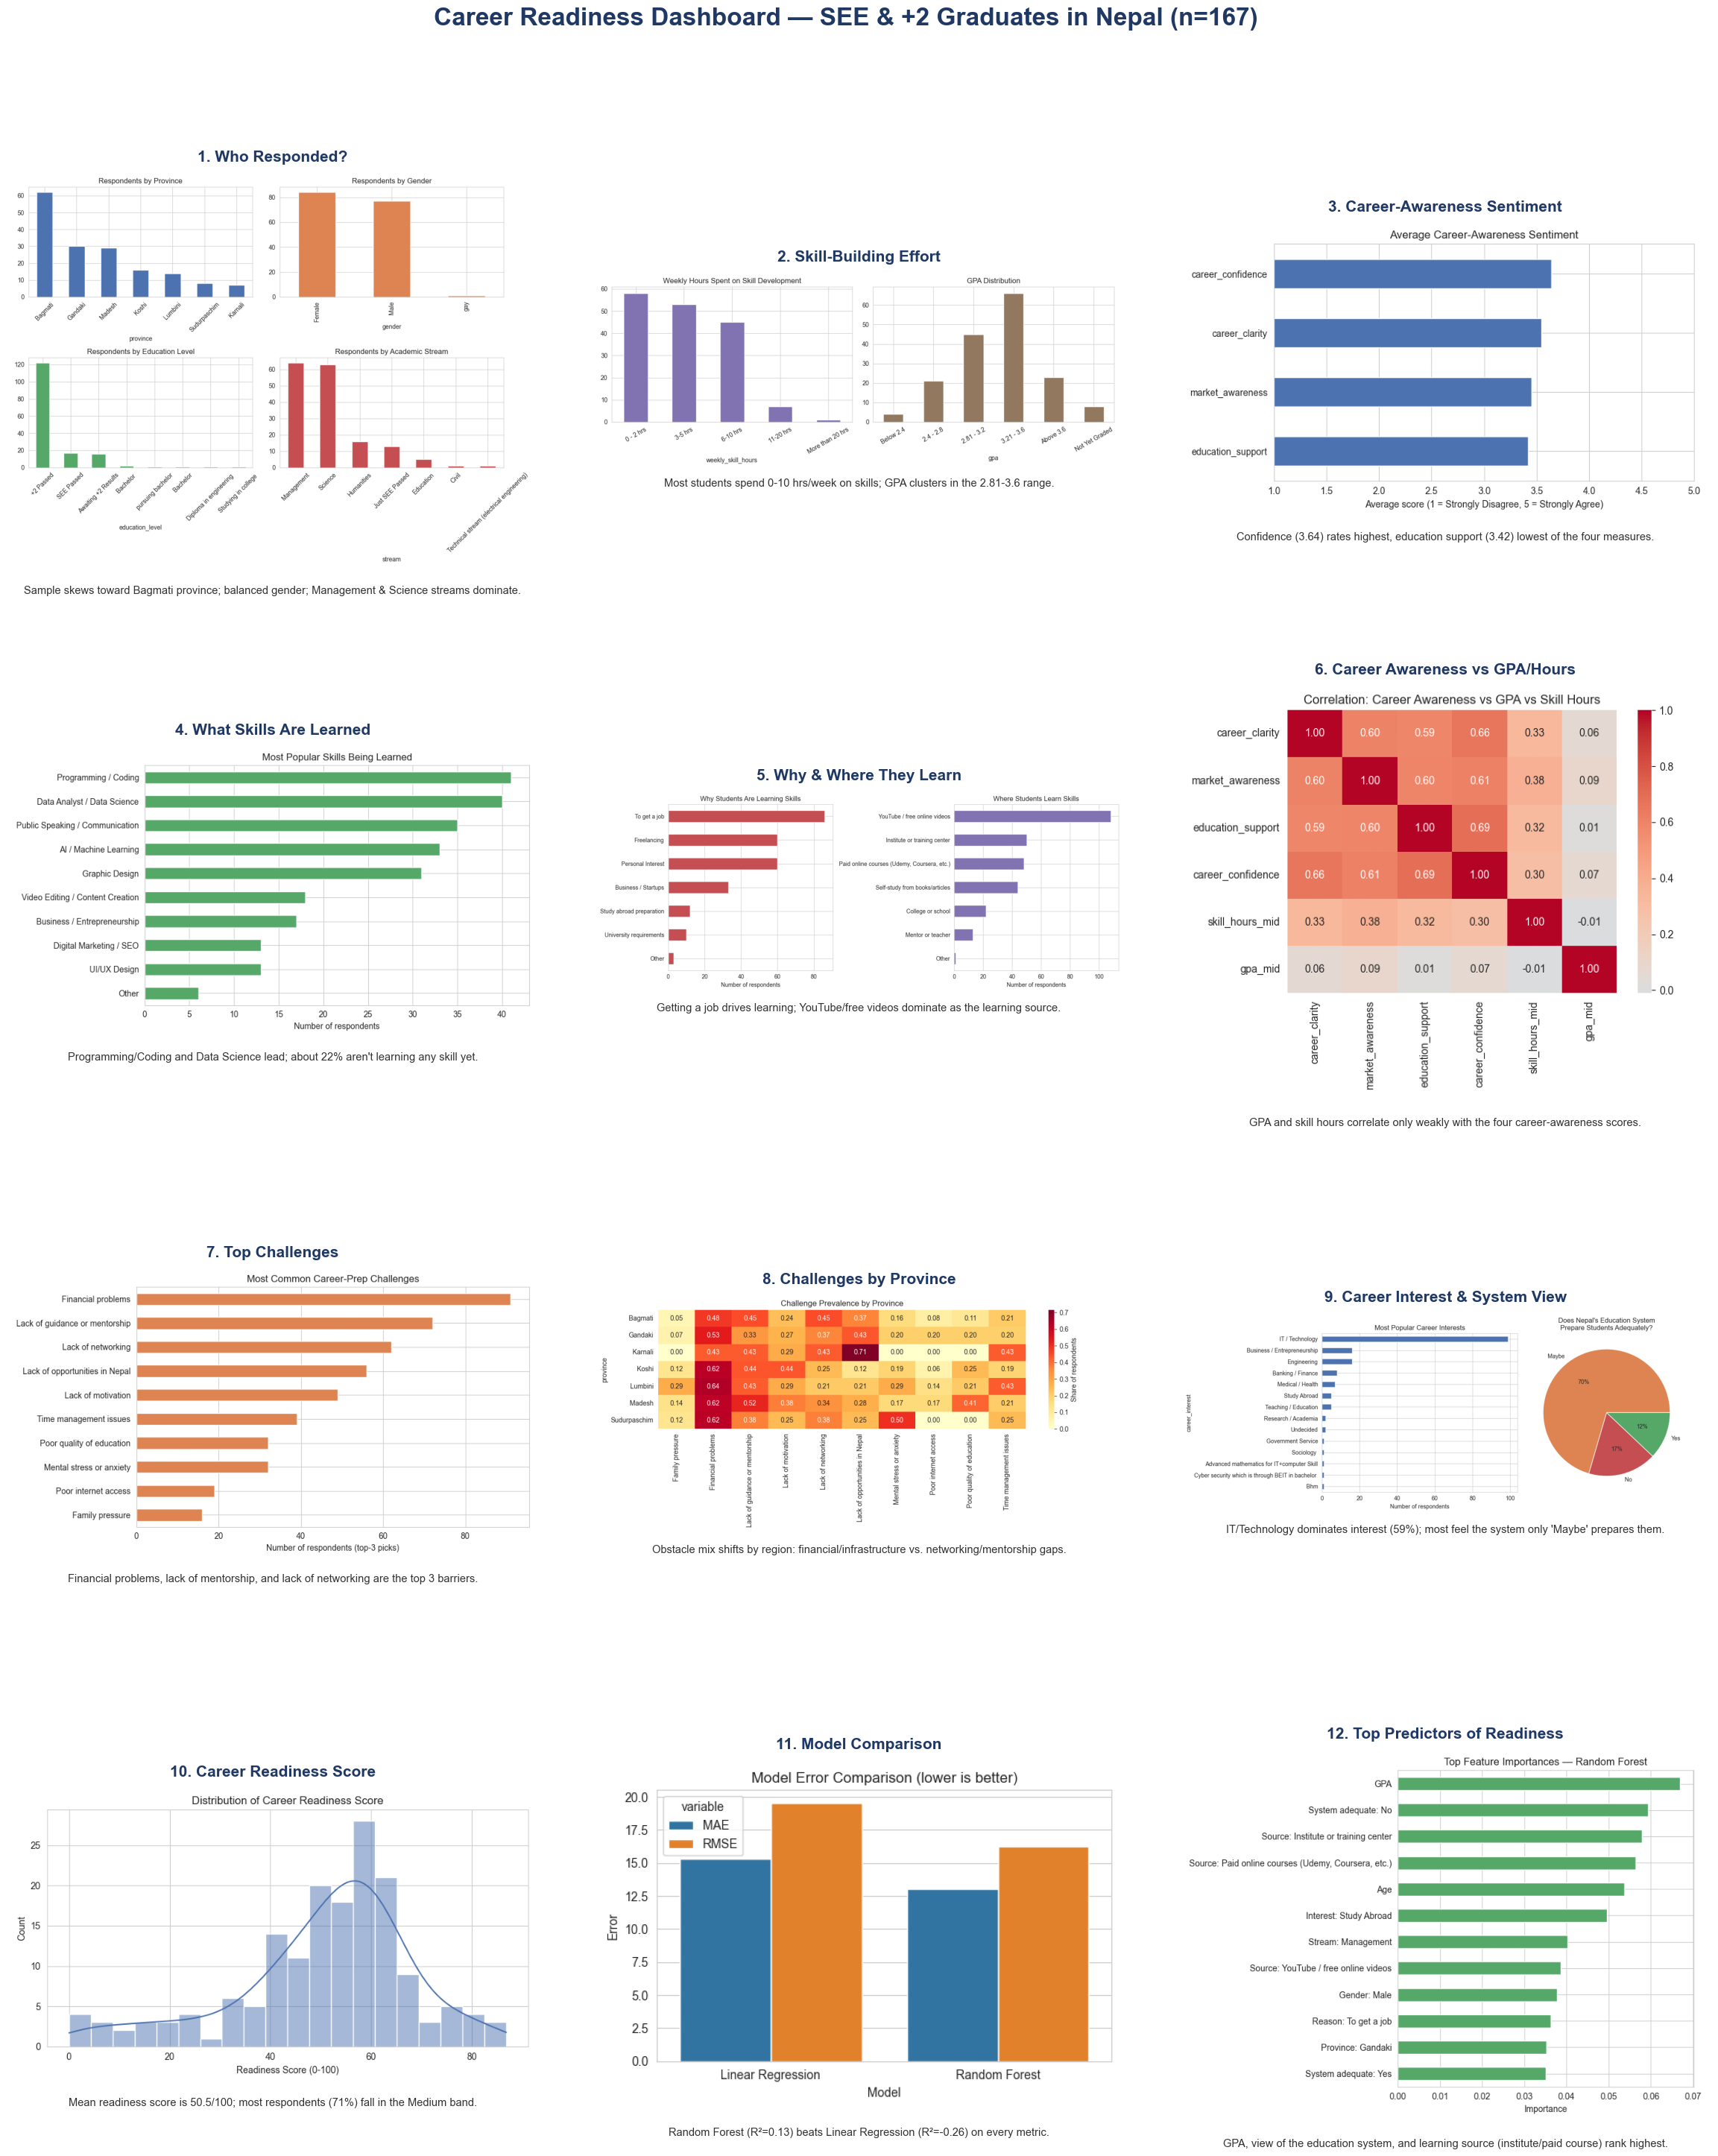

Saved phase6_dashboard.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

panels = [
    ("phase2_demographics.png", "1. Who Responded?",
     "Sample skews toward Bagmati province; balanced gender; Management & Science streams dominate."),
    ("phase2_hours_gpa.png", "2. Skill-Building Effort",
     "Most students spend 0-10 hrs/week on skills; GPA clusters in the 2.81-3.6 range."),
    ("phase2_likert_means.png", "3. Career-Awareness Sentiment",
     "Confidence (3.64) rates highest, education support (3.42) lowest of the four measures."),
    ("phase2_top_skills.png", "4. What Skills Are Learned",
     "Programming/Coding and Data Science lead; about 22% aren't learning any skill yet."),
    ("phase2_reason_source.png", "5. Why & Where They Learn",
     "Getting a job drives learning; YouTube/free videos dominate as the learning source."),
    ("phase2_correlation.png", "6. Career Awareness vs GPA/Hours",
     "GPA and skill hours correlate only weakly with the four career-awareness scores."),
    ("phase2_top_challenges.png", "7. Top Challenges",
     "Financial problems, lack of mentorship, and lack of networking are the top 3 barriers."),
    ("phase2_challenges_by_province.png", "8. Challenges by Province",
     "Obstacle mix shifts by region: financial/infrastructure vs. networking/mentorship gaps."),
    ("phase2_interest_system.png", "9. Career Interest & System View",
     "IT/Technology dominates interest (59%); most feel the system only 'Maybe' prepares them."),
    ("phase3_readiness_distribution.png", "10. Career Readiness Score",
     "Mean readiness score is 50.5/100; most respondents (71%) fall in the Medium band."),
    ("phase4_model_comparison.png", "11. Model Comparison",
     "Random Forest (R\u00b2=0.13) beats Linear Regression (R\u00b2=-0.26) on every metric."),
    ("phase4_feature_importance.png", "12. Top Predictors of Readiness",
     "GPA, view of the education system, and learning source (institute/paid course) rank highest."),
]

fig, axes = plt.subplots(4, 3, figsize=(24, 30))

for ax, (fname, title, caption) in zip(axes.flat, panels):
    img = mpimg.imread(fname)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=15, fontweight="bold", color="#1F3864", pad=10)
    ax.text(0.5, -0.04, caption, transform=ax.transAxes, ha="center", va="top",
            fontsize=10.5, color="#333333", wrap=True)

fig.suptitle("Career Readiness Dashboard — SEE & +2 Graduates in Nepal (n=167)",
              fontsize=24, fontweight="bold", color="#1F3864", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("phase6_dashboard.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved phase6_dashboard.png")
